# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Total rows: 1000
Percentage of likes: 50.0%


<Axes: title={'center': 'Percentage of Likes vs Non-Likes'}, xlabel='Liked'>

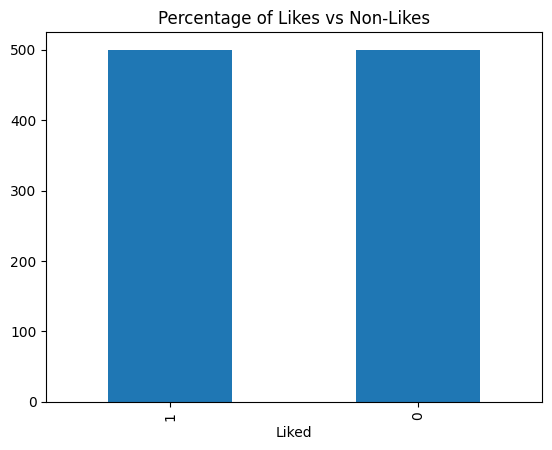

In [2]:
# Add code here 🔧
print(f"Total rows: {len(df)}")

liked_pct = df['Liked'].mean() * 100
print(f"Percentage of likes: {liked_pct}%")

df['Liked'].value_counts().plot(kind='bar', title='Percentage of Likes vs Non-Likes')

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [3]:
# Add code here 🔧
import re

df['Review'] = df['Review'].str.lower().replace(r'[^a-z0-0\s]', '', regex=True)

df.head()

,Review,Liked
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


### ✍️ Your Response: 🔧
1. If you leave punctuation, symbols, and URLs the model will likely get the model confused. cleaning up ensures model sees actual meaning of words without getting disctracted.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [4]:
# Add code here 🔧
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['scores'] = df['Review'].apply(lambda x: analyzer.polarity_scores(x))

df['sentiment'] = df['scores'].apply(lambda score: 'positive' if score['compound'] >= 0.05
                                     else ('negative' if score['compound'] <= -0.05 else 'neutral'))
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100
print(sentiment_counts)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00
sentiment
positive    50.6
negative    25.5
neutral     23.9
Name: proportion, dtype: float64


### ✍️ Your Response: 🔧
1. the positive is different than liked. Vader picks up neutral and mild than just a 1 or 2.

2. Negative reviews are the best for owners. they tell you what is wrong so you can fix it. Neutral reviews are also big because those are customers you could easily win over.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to resolve LookupError

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)

    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned)

df['processed_review'] = df['Review'].apply(preprocess_text)

print(df['processed_review'].head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                           selection menu great price
5                          getting angry want damn pho
6                           honeslty didnt taste fresh
7    potato like rubber could tell made ahead time ...
8                                            fry great
9                                          great touch
Name: processed_review, dtype: object


### ✍️ Your Response: 🔧
1. Corpora is like a massive library of text data. it is used as a reference so model knows rules of a language

2. ["wow", "loved", "this", "Place"]

3. It chops words down to their dictionary root. It helps models realize they're all talking about same vibe.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [8]:
# Add code here 🔧
!pip install gensim
from gensim.corpora import Dictionary

tokenized_docs = [doc.split() for doc in df['processed_review']]

id2word = Dictionary(tokenized_docs)

corpus = [id2word.doc2bow(doc) for doc in tokenized_docs]

print(f"Dictionary length: {len(id2word)}")
print(f"Corpus length: {len(corpus)}")

print(f"First review BOW: {corpus[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.7 MB/s eta 0:00:00
Dictionary length: 1814
Corpus length: 1000
First review BOW: [(0, 1), (1, 1), (2, 1)]


### ✍️ Your Response: 🔧
1. Corpus is a digital collection of all processed reviews, but converted to numbers. It is useful because models can't "read" english, they need math.

2. The dictionary is the key and corpus uses the IDs assigned to build data set

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [9]:
# Add code here 🔧
from gensim.models import LdaModel

num_topics = 5

lda_model = LdaModel(corpus=corpus,
                     id2word=id2word,
                     num_topics=num_topics,
                     passes=10,
                     random_state=42)

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.028*"food" + 0.027*"good" + 0.022*"place" + 0.014*"0" + 0.011*"service" + 0.010*"minute" + 0.009*"never" + 0.009*"time" + 0.008*"would" + 0.007*"like"

Topic: 1 
Words: 0.016*"great" + 0.012*"time" + 0.012*"go" + 0.012*"place" + 0.009*"food" + 0.009*"service" + 0.009*"back" + 0.009*"like" + 0.008*"love" + 0.007*"eat"

Topic: 2 
Words: 0.039*"service" + 0.020*"food" + 0.012*"time" + 0.011*"dont" + 0.011*"like" + 0.010*"great" + 0.009*"restaurant" + 0.008*"good" + 0.008*"dish" + 0.007*"nice"

Topic: 3 
Words: 0.033*"place" + 0.024*"food" + 0.017*"good" + 0.017*"really" + 0.014*"best" + 0.011*"one" + 0.010*"great" + 0.009*"amazing" + 0.008*"steak" + 0.008*"restaurant"

Topic: 4 
Words: 0.024*"back" + 0.009*"great" + 0.009*"good" + 0.008*"wont" + 0.008*"place" + 0.008*"go" + 0.008*"experience" + 0.008*"friendly" + 0.007*"burger" + 0.007*"also"



### ✍️ Your Response: 🔧
1. You want to use more than five if you have a super big dataset or business is very complex.

2. If you start seeing overlapping topics you have too many.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


Topic: 0 
Words: 0.028*"food" + 0.027*"good" + 0.022*"place" + 0.014*"0" + 0.011*"service" + 0.010*"minute" + 0.009*"never" + 0.009*"time" + 0.008*"would" + 0.007*"like"

Topic: 1 
Words: 0.016*"great" + 0.012*"time" + 0.012*"go" + 0.012*"place" + 0.009*"food" + 0.009*"service" + 0.009*"back" + 0.009*"like" + 0.008*"love" + 0.007*"eat"

Topic: 2 
Words: 0.039*"service" + 0.020*"food" + 0.012*"time" + 0.011*"dont" + 0.011*"like" + 0.010*"great" + 0.009*"restaurant" + 0.008*"good" + 0.008*"dish" + 0.007*"nice"

Topic: 3 
Words: 0.033*"place" + 0.024*"food" + 0.017*"good" + 0.017*"really" + 0.014*"best" + 0.011*"one" + 0.010*"great" + 0.009*"amazing" + 0.008*"steak" + 0.008*"restaurant"

Topic: 4 
Words: 0.024*"back" + 0.009*"great" + 0.009*"good" + 0.008*"wont" + 0.008*"place" + 0.008*"go" + 0.008*"experience" + 0.008*"friendly" + 0.007*"burger" + 0.007*"also"

sentiment    negative    neutral   positive  count
main_topic                                        
0           31.527094  24.

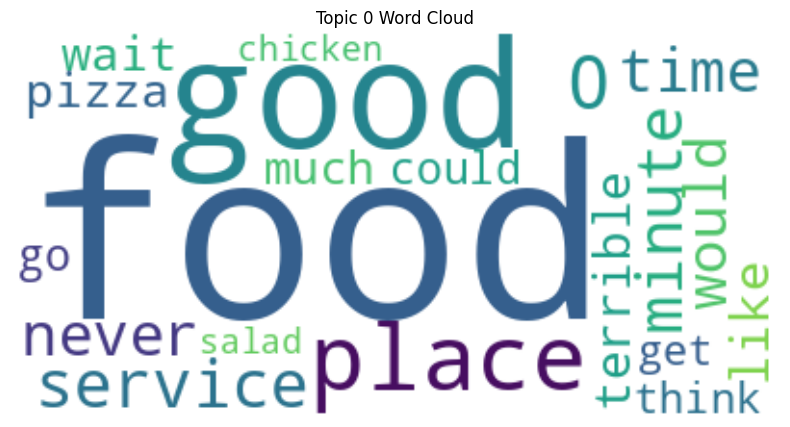

In [10]:
# Add code here 🔧
import matplotlib.pyplot as plt
from wordcloud import WordCloud

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")


def get_main_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

df['main_topic'] = [get_main_topic(b) for b in corpus]

topic_summary = df.groupby('main_topic')['sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100
topic_summary['count'] = df['main_topic'].value_counts()
print(topic_summary)

wordcloud = WordCloud(background_color='white').generate_from_frequencies(dict(lda_model.show_topic(0, 20)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Topic 0 Word Cloud')
plt.show()

### ✍️ Your Response: 🔧
List your topics and names here:
sevice delay
general positive
customer interaction
high quality dining
returning for classics


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. the model helps answer what is the biggest driver of negative reviews. Even though 50 percent of people liked the place, the model shows that topic 0 (wait time) is the main reason people leave unhappy,

2. I recommend people focus on speed of service and kitchen efficiency. Since the wait time has the most negative sentiment, fixing that would turn negative into neutral or positive reviews.

3. Pros: LLM way faster at understanding contex/sarcasm and doesn't need cleaning. Cons: lose transparency of the math. with python you see exactly which words define a topic, LLM it is a bit of a black box.

4. You are a business data analyst. i am providing 1000 reviews. Please perform sentiment analysis on each and then group them into five distinct topics. for each topic provide a name, the percentag of reviews that fall into it, and overall sentiment for that group.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [11]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 564595 bytes to assignment_13_text_analytics.html
